In [1]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader

# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_input import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = os.listdir(test_image_path)
test_mask_list_orig = os.listdir(test_mask_path)

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = os.listdir(trainval_image_path)
trainval_mask_list_orig = os.listdir(trainval_mask_path)
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# 0. Image samples Visualization

In [2]:
N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/Dataset/TrainVal/color/Abyssinian_184.jpg 
 Dataset/Dataset/TrainVal/label/Abyssinian_184.png


Dataset/Dataset/TrainVal/color/american_bulldog_192.jpg 
 Dataset/Dataset/TrainVal/label/american_bulldog_192.png


# Image Input

# 1.  Dataset preprocessing and augmentation

In [27]:


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


Image batch shape: torch.Size([64, 3, 240, 240]), Mask batch shape: torch.Size([64, 240, 240])


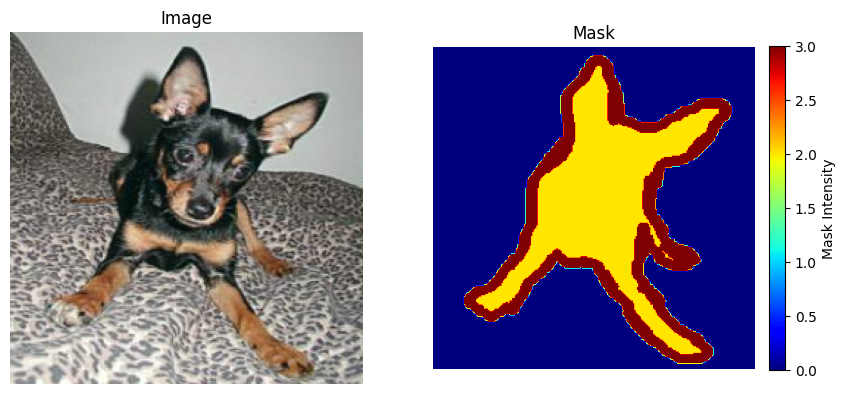

In [32]:
N=random.randint(0,BATCH_SIZE)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])